In [88]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.utils.validation import check_is_fitted
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

In [89]:
def print_evaluation(y_true, y_pred, clf_name="Model"):
    print(f"\n=== Evaluation: {clf_name} ===")
    print("Accuracy:  {:.4f}".format(accuracy_score(y_true, y_pred)))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=dataset.target_names))
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)
    return cm

In [90]:
def plot_confusion_matrix(cm, ax, title="Confusion Matrix"):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=dataset.target_names, yticklabels=dataset.target_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

In [91]:
def plot_decision_boundary_2d(ax, model, X2d, y, plot_support=True, label=None, linestyle="-", linewidth=1.5, color=None):
    """
    Plot decision boundary (zero iso-contour of decision_function) on 2D feature space.
    - model must support decision_function
    - X2d is any 2D array of points to scatter (e.g., X_test_pca)
    - support vectors are taken from model.support_vectors_ (safe, no indexing errors)
    """
    x_min, x_max = X2d[:, 0].min() - 1.0, X2d[:, 0].max() + 1.0
    y_min, y_max = X2d[:, 1].min() - 1.0, X2d[:, 1].max() + 1.0
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    # decision_function expects same feature space as model was trained on
    grid = np.c_[xx.ravel(), yy.ravel()]
    try:
        Z = model.decision_function(grid)
    except Exception as e:
        # some classifiers might not have decision_function; try predict_proba fallback
        try:
            Z = model.predict_proba(grid)[:, 1] - 0.5
        except Exception:
            raise RuntimeError("Model has neither decision_function nor predictable proba.") from e

    Z = Z.reshape(xx.shape)
    # main decision boundary (level 0)
    cs = ax.contour(xx, yy, Z, levels=[0], linewidths=linewidth, linestyles=linestyle, colors=[color or 'k'])
    # margins
    ax.contour(xx, yy, Z, levels=[-1, 1], linewidths=0.8, linestyles='--', colors=[color or 'k'], alpha=0.6)
    # scatter samples
    ax.scatter(X2d[:, 0], X2d[:, 1], c=y, cmap='coolwarm', s=20, edgecolor='k', alpha=0.6)
    # plot support vectors using support_vectors_ (these are already in the model's feature space)
    if plot_support and hasattr(model, "support_vectors_"):
        sv = model.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], facecolors='none', edgecolors=color or 'k', s=100, linewidths=1.5, label=f"SV ({label})")
    if label and hasattr(cs, "collections") and len(cs.collections) > 0:
        cs.collections[0].set_label(label)
    return cs

In [92]:
dataset = load_breast_cancer()
X = dataset.data
y = dataset.target

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

In [94]:
kernels = {
    "Linear (C=1)": SVC(kernel='linear', C=1.0, probability=False, random_state=42),
    "Poly (deg=3, C=1)": SVC(kernel='poly', degree=3, C=1.0, probability=False, random_state=42),
    "RBF (gamma=0.1, C=1)": SVC(kernel='rbf', gamma=0.1, C=1.0, probability=False, random_state=42),
}

=== Training & evaluating kernel SVMs on full feature set (scaled) ===

=== Evaluation: Linear (C=1) ===
Accuracy:  0.9825

Classification report:
              precision    recall  f1-score   support

   malignant       0.98      0.97      0.98        64
      benign       0.98      0.99      0.99       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171

Confusion Matrix:
 [[ 62   2]
 [  1 106]]

=== Evaluation: Poly (deg=3, C=1) ===
Accuracy:  0.8947

Classification report:
              precision    recall  f1-score   support

   malignant       1.00      0.72      0.84        64
      benign       0.86      1.00      0.92       107

    accuracy                           0.89       171
   macro avg       0.93      0.86      0.88       171
weighted avg       0.91      0.89      0.89       171

Confusion Matrix:
 [[ 46  18]
 [  0 107]]

=== Evaluation: RBF (gamma=0.1, C

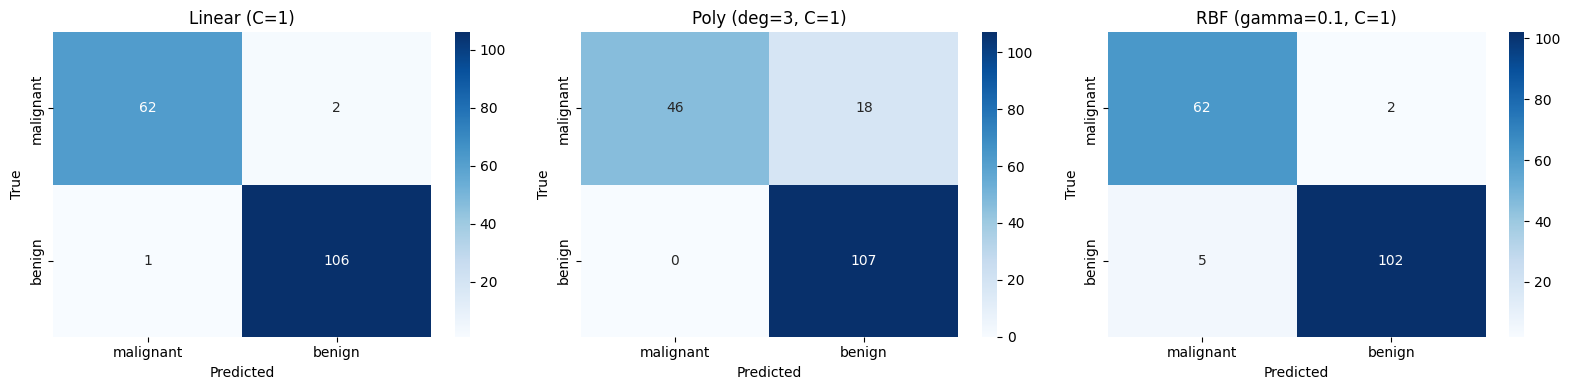

In [95]:
results = {}
print("=== Training & evaluating kernel SVMs on full feature set (scaled) ===")
for name, clf in kernels.items():
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)
    cm = print_evaluation(y_test, y_pred, clf_name=name)
    results[name] = {"clf": clf, "confusion_matrix": cm, "y_pred": y_pred}

fig, axes = plt.subplots(1, len(kernels), figsize=(16, 4))
for ax, (name, res) in zip(axes, results.items()):
    plot_confusion_matrix(res["confusion_matrix"], ax, title=name)
plt.tight_layout()
plt.show()

In [96]:
pca = PCA(n_components=2, random_state=42)
pca.fit(X_train_s)
X_train_pca = pca.transform(X_train_s)
X_test_pca = pca.transform(X_test_s)

In [97]:
clfs_margin = {
    "Hard (C=1e5)": SVC(kernel='linear', C=1e5, random_state=42),
    "Soft (C=1)": SVC(kernel='linear', C=1.0, random_state=42),
    "Softer (C=0.01)": SVC(kernel='linear', C=0.01, random_state=42),
}

for name, clf in clfs_margin.items():
    clf.fit(X_train_pca, y_train)

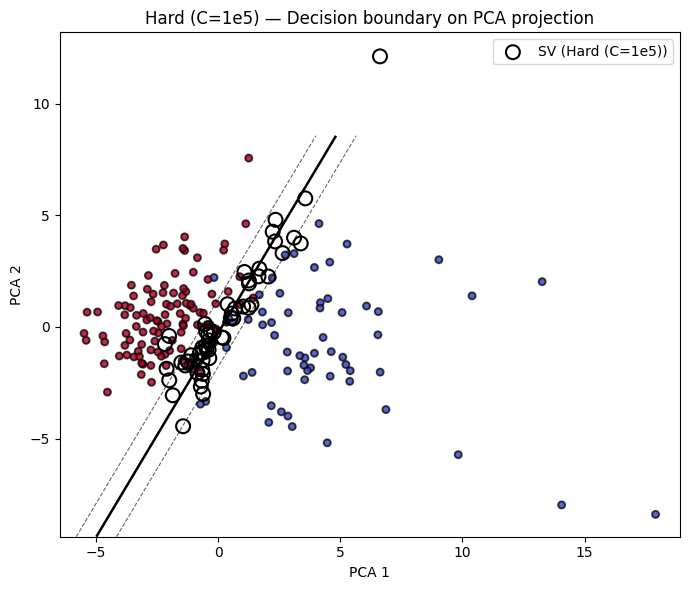

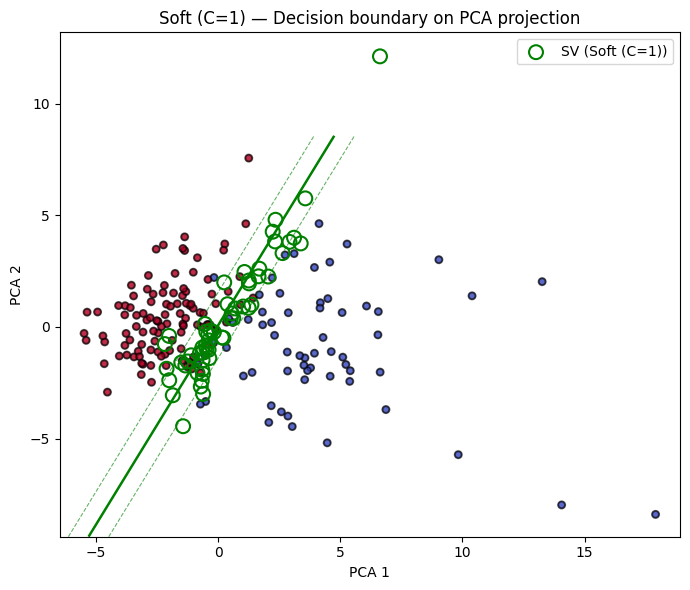

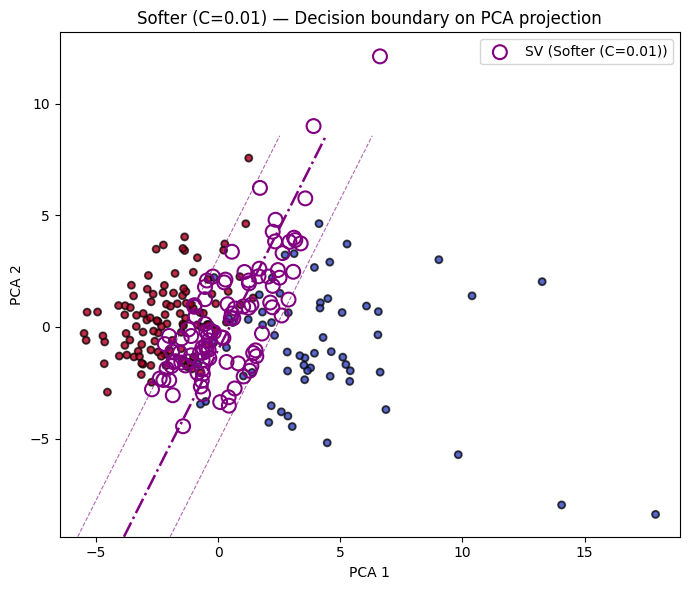

In [98]:
# plot each margin-model in its own figure (3 separate plots)
colors = {"Hard (C=1e5)": "black", "Soft (C=1)": "green", "Softer (C=0.01)": "purple"}
linestyles = {"Hard (C=1e5)": "-", "Soft (C=1)": "-", "Softer (C=0.01)": "-."}

for name, clf in clfs_margin.items():
    fig, ax = plt.subplots(figsize=(7, 6))
    # scatter the test points
    ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', s=30, edgecolor='k', alpha=0.6)
    # draw decision boundary + margins + support vectors (uses support_vectors_)
    plot_decision_boundary_2d(
        ax,
        clf,
        X_test_pca,
        y_test,
        plot_support=True,
        label=name,
        linestyle=linestyles[name],
        linewidth=1.8,
        color=colors[name]
    )
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    ax.set_title(f"{name} — Decision boundary on PCA projection")
    ax.legend()
    plt.tight_layout()
    plt.show()
    # optional: save each figure
    # fig.savefig(f"svm_{name.replace(' ', '_').replace('(', '').replace(')', '')}.png", dpi=200)


In [99]:
print("\n=== Performance of PCA-2D linear SVMs (for visualization only) ===")
for name, clf in clfs_margin.items():
    y_pred_pca = clf.predict(X_test_pca)
    print_evaluation(y_test, y_pred_pca, clf_name=f"PCA-2D {name}")


=== Performance of PCA-2D linear SVMs (for visualization only) ===

=== Evaluation: PCA-2D Hard (C=1e5) ===
Accuracy:  0.9591

Classification report:
              precision    recall  f1-score   support

   malignant       0.94      0.95      0.95        64
      benign       0.97      0.96      0.97       107

    accuracy                           0.96       171
   macro avg       0.96      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171

Confusion Matrix:
 [[ 61   3]
 [  4 103]]

=== Evaluation: PCA-2D Soft (C=1) ===
Accuracy:  0.9415

Classification report:
              precision    recall  f1-score   support

   malignant       0.89      0.97      0.93        64
      benign       0.98      0.93      0.95       107

    accuracy                           0.94       171
   macro avg       0.93      0.95      0.94       171
weighted avg       0.94      0.94      0.94       171

Confusion Matrix:
 [[62  2]
 [ 8 99]]

=== Evaluation: PCA-2D Softer (C=

In [100]:
kernel_2d_clfs = {
    "Linear": SVC(kernel='linear', C=1.0, random_state=42),
    "Poly (deg=3)": SVC(kernel='poly', degree=3, C=1.0, random_state=42),
    "RBF (gamma=0.1)": SVC(kernel='rbf', gamma=0.1, C=1.0, random_state=42),
}

Linear not fitted — fitting now...
Poly (deg=3) not fitted — fitting now...
RBF (gamma=0.1) not fitted — fitting now...


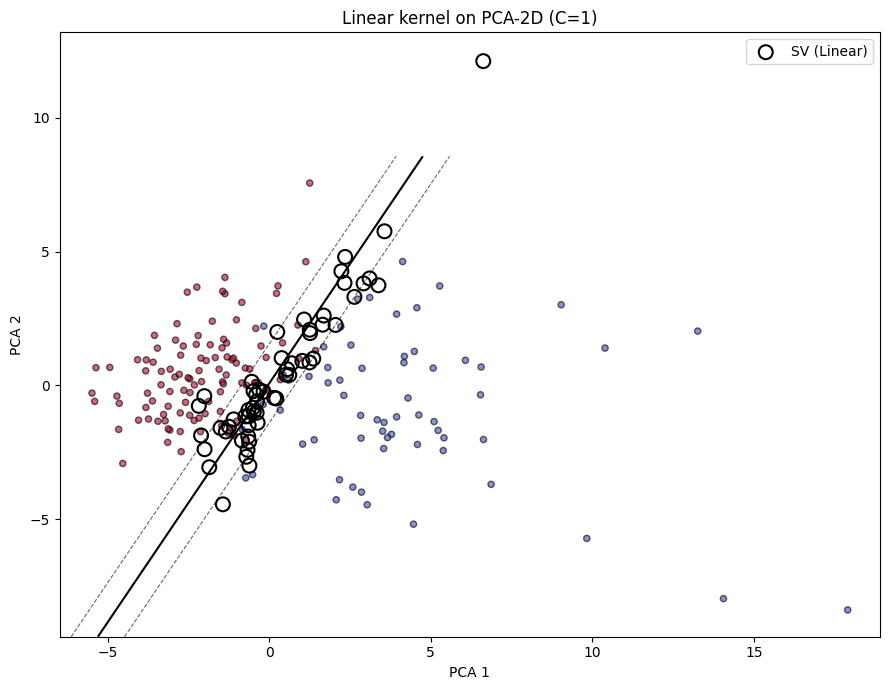

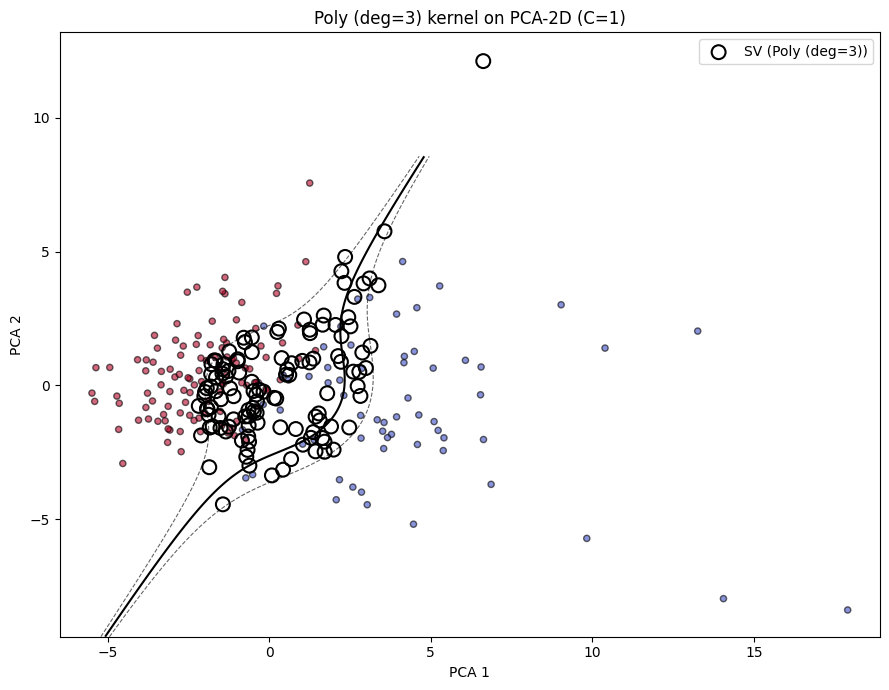

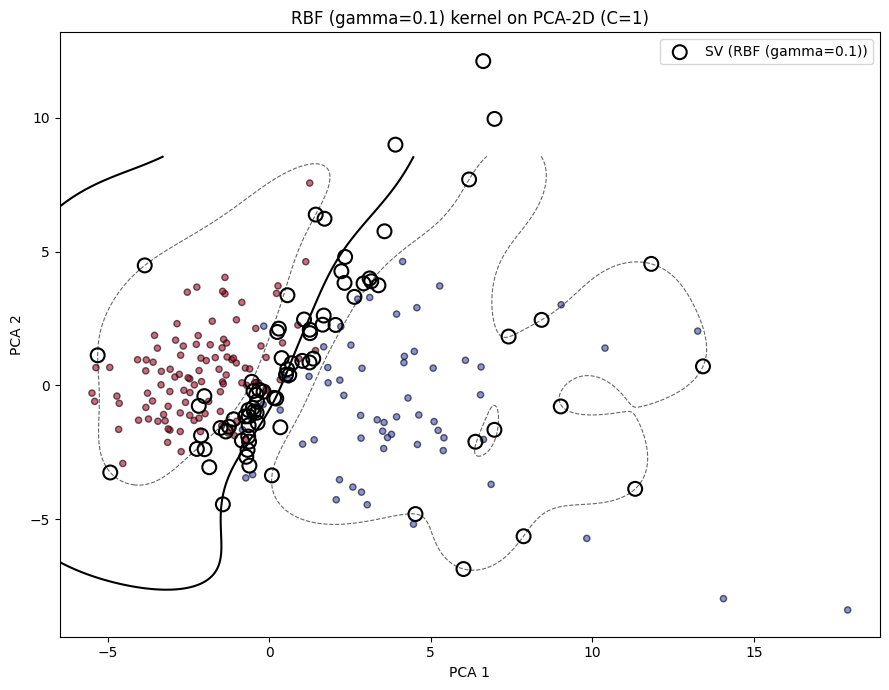

In [101]:
# Ensure each kernel classifier is fitted (fit if not)
for name, clf in kernel_2d_clfs.items():
    try:
        check_is_fitted(clf)            # will raise if not fitted
        # if no exception: already fitted
        print(f"{name} is already fitted.")
    except Exception:
        print(f"{name} not fitted — fitting now...")
        clf.fit(X_train_pca, y_train)

# Now plot each kernel in its own window (large figure)
for name, clf in kernel_2d_clfs.items():
    fig, ax = plt.subplots(figsize=(9, 7))
    # plot decision boundary + margins + support vectors
    plot_decision_boundary_2d(
        ax,
        clf,
        X_test_pca,
        y_test,
        plot_support=True,
        label=name,
        linestyle='-',
        linewidth=1.5,
        color=None
    )
    ax.set_title(f"{name} kernel on PCA-2D (C=1)")
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    ax.legend()
    plt.tight_layout()
    plt.show()
    plt.close(fig)
